##Full ML + Deep Learning Pipeline with Visualization

##Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

##Generate Dataset

In [2]:
X, y = make_classification(n_samples=1000, n_features=2, n_informative=1, n_redundant=0, n_repeated=0, n_classes=2, n_clusters_per_class=1, random_state=42)

##Visualize Raw Data

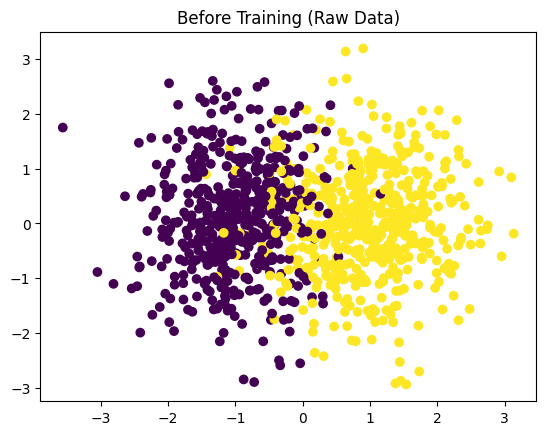

In [3]:

plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Before Training (Raw Data)")
plt.show()


##Split and Scale

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

##Train ML Model

In [5]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [6]:
# Predictions
preds = model.predict(X_test)

# Evaluation
acc = accuracy_score(y_test, preds)
print("ML Model Accuracy:", acc)

ML Model Accuracy: 0.92


##Confusion Matrix

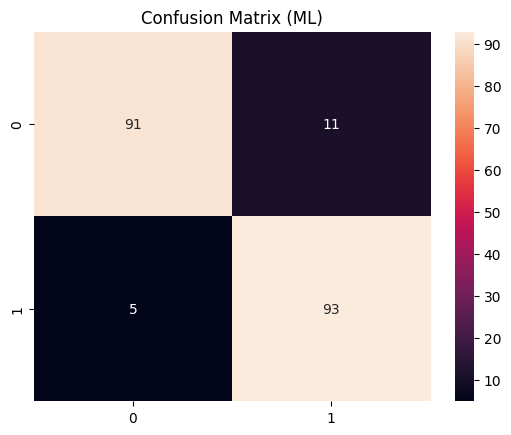

In [7]:
cm = confusion_matrix(y_test, preds)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (ML)")
plt.show()


##Deep Learning Model

In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

##Build model

In [10]:
nn = Sequential([
    Dense(16, activation='relu', input_shape=(2,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


## Train

In [11]:
history = nn.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test), verbose=0)


##Plot training

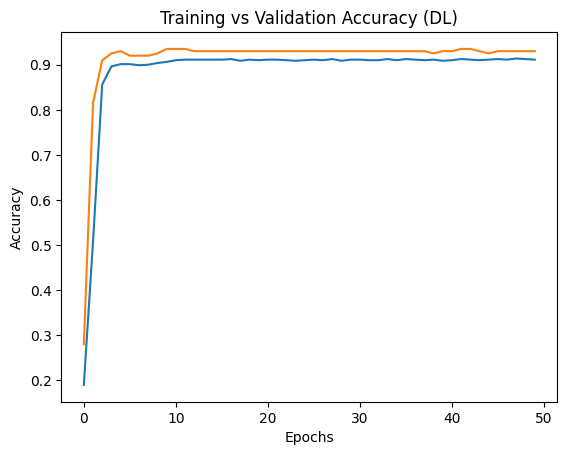

In [12]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Training vs Validation Accuracy (DL)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

##Evaluate

In [13]:
loss, acc_dl = nn.evaluate(X_test, y_test, verbose=0)
print("Deep Learning Accuracy:", acc_dl)

Deep Learning Accuracy: 0.9300000071525574


##Predictions

In [14]:
preds_dl = (nn.predict(X_test) > 0.5).astype(int)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


##Confusion Matrix DL

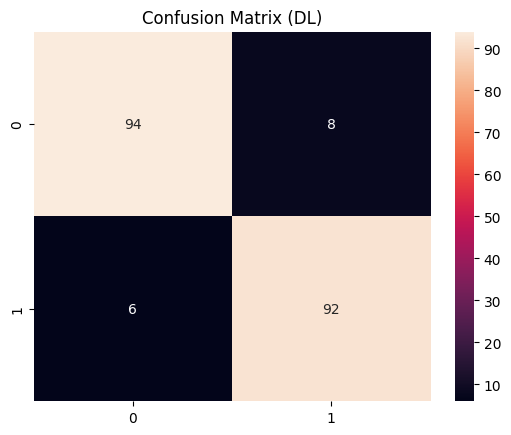

In [15]:
cm_dl = confusion_matrix(y_test, preds_dl)
plt.figure()
sns.heatmap(cm_dl, annot=True, fmt='d')
plt.title("Confusion Matrix (DL)")
plt.show()


## Decision Boundary Visualization

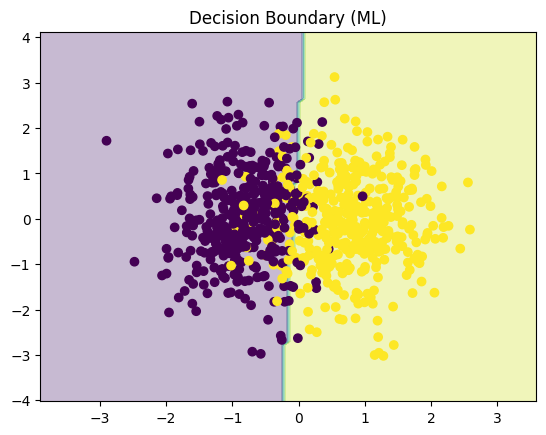

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


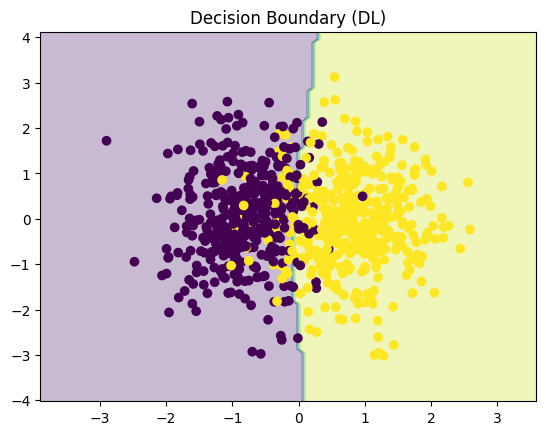

In [18]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    if len(Z.shape) > 1:
        Z = (Z > 0.5).astype(int)
    Z = Z.reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title(title)
    plt.show()
# ML boundary
plot_decision_boundary(model, X_train, y_train, "Decision Boundary (ML)")

# DL boundary
plot_decision_boundary(nn, X_train, y_train, "Decision Boundary (DL)")
